In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# 1. Load the Anchor Table (Courses)
courses_df = pd.read_csv('data/courses.csv')

# 2. Load the Demographic/Outcome Table (Student Info)
student_info_df = pd.read_csv('data/studentInfo.csv')

# 3. Print the verification metrics
print("--- Courses Info ---")
print(courses_df.info())
print("\n--- Student Info ---")
print(student_info_df.info())
print("\n--- Missing Values in Student Info ---")
print(student_info_df.isnull().sum())

--- Courses Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 3 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   code_module                 22 non-null     object
 1   code_presentation           22 non-null     object
 2   module_presentation_length  22 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 660.0+ bytes
None

--- Student Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   code_module           32593 non-null  object
 1   code_presentation     32593 non-null  object
 2   id_student            32593 non-null  int64 
 3   gender                32593 non-null  object
 4   region                32593 non-null  object
 5   highest_education     32593 non-null  object
 6   i

In [5]:
# 1. Load the required tables
assessments = pd.read_csv('data/assessments.csv')
student_assessments = pd.read_csv('data/studentAssessment.csv')
student_info = pd.read_csv('data/studentInfo.csv')

# 2. Merge to get deadline dates alongside actual submission dates
df_assess = pd.merge(student_assessments, assessments, on='id_assessment', how='left')

# 3. Create the 'is_late' flag
# A submission is late if 'date_submitted' is greater than the deadline 'date'
df_assess['is_late'] = np.where(df_assess['date_submitted'] > df_assess['date'], 1, 0)

# 4. Aggregate to the student level (per module and presentation)
# If a student was late at least once, we flag them as high risk (1)
student_risk = df_assess.groupby(['id_student', 'code_module', 'code_presentation'])['is_late'].max().reset_index()
student_risk.rename(columns={'is_late': 'high_risk'}, inplace=True)

# 5. Merge with student_info to create our master target dataframe
target_df = pd.merge(student_info, student_risk, on=['id_student', 'code_module', 'code_presentation'], how='left')

# 6. Handle missing values
# Students with absolutely NO assessment records missed everything (High Risk = 1)
target_df['high_risk'] = target_df['high_risk'].fillna(1).astype(int)

# 7. Print the verification metrics
print("--- Target Distribution (%) ---")
print(target_df['high_risk'].value_counts(normalize=True) * 100)
print("\n--- Target Dataframe Shape ---")
print(target_df.shape)

--- Target Distribution (%) ---
high_risk
1    67.799834
0    32.200166
Name: proportion, dtype: float64

--- Target Dataframe Shape ---
(32593, 13)


In [6]:
# 1. Load the VLE (Virtual Learning Environment) data
print("Loading VLE data... this might take a minute or two.")
vle_df = pd.read_csv('data/studentVle.csv')

# 2. Aggregate behavioral metrics per student per course presentation
print("Aggregating behavioral features...")
vle_features = vle_df.groupby(['id_student', 'code_module', 'code_presentation']).agg(
    total_clicks=('sum_click', 'sum'),
    active_days=('date', 'nunique')
).reset_index()

# 3. Merge these new features into our existing target_df
print("Merging features with the master dataframe...")
# This uses the target_df you created in the previous cell
master_df = pd.merge(target_df, vle_features, on=['id_student', 'code_module', 'code_presentation'], how='left')

# 4. Handle missing VLE data 
# If a student never logged in, they won't be in the VLE table. We must fill these with 0.
master_df['total_clicks'] = master_df['total_clicks'].fillna(0)
master_df['active_days'] = master_df['active_days'].fillna(0)

# 5. Print the verification metrics
print("--- Master DataFrame Shape ---")
print(master_df.shape)
print("\n--- Summary of New Features ---")
print(master_df[['total_clicks', 'active_days']].describe())

Loading VLE data... this might take a minute or two.
Aggregating behavioral features...
Merging features with the master dataframe...
--- Master DataFrame Shape ---
(32593, 15)

--- Summary of New Features ---
       total_clicks   active_days
count  32593.000000  32593.000000
mean    1215.141257     55.475685
std     1692.604449     54.515290
min        0.000000      0.000000
25%      142.000000     11.000000
50%      602.000000     40.000000
75%     1585.000000     85.000000
max    24139.000000    286.000000


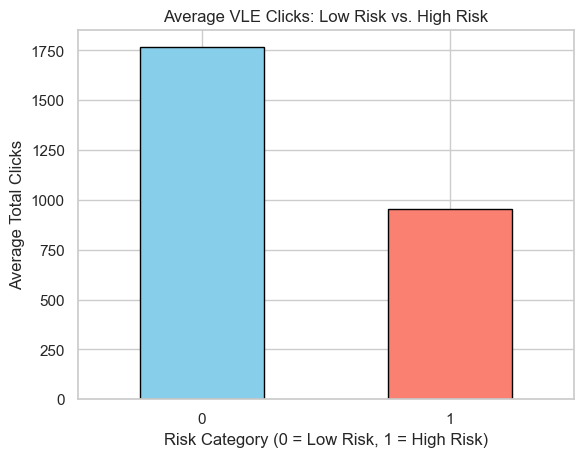

In [9]:
# Calculate the average clicks for Low Risk (0) vs High Risk (1)
avg_clicks = master_df.groupby('high_risk')['total_clicks'].mean()

# Create a simple bar chart
avg_clicks.plot(kind='bar', color=['skyblue', 'salmon'], edgecolor='black')

plt.title('Average VLE Clicks: Low Risk vs. High Risk')
plt.xlabel('Risk Category (0 = Low Risk, 1 = High Risk)')
plt.ylabel('Average Total Clicks')
plt.xticks(rotation=0) # Keeps the labels flat

# Display the plot
plt.show()